In [1]:
import pandas as pd
import sqlite3

print("套件載入成功！")

套件載入成功！


In [3]:
# 建立資料庫
conn = sqlite3.connect("C:/Users/acer/olist_project/olist.db")

# 載入所有表
tables = {
    "orders": "olist_orders_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "order_payments": "olist_order_payments_dataset.csv",
    "order_reviews": "olist_order_reviews_dataset.csv",
    "customers": "olist_customers_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "products": "olist_products_dataset.csv",
    "category_translation": "product_category_name_translation.csv",
    "geolocation": "olist_geolocation_dataset.csv",
}

path = "C:/Users/acer/olist_project/"

for table_name, filename in tables.items():
    df = pd.read_csv(path + filename)
    df.to_sql(table_name, conn, if_exists="replace", index=False)
    print(f"✅ {table_name} 載入完成，共 {len(df)} 筆")

print("\n🎉 所有資料載入完成！")

✅ orders 載入完成，共 99441 筆
✅ order_items 載入完成，共 112650 筆
✅ order_payments 載入完成，共 103886 筆
✅ order_reviews 載入完成，共 99224 筆
✅ customers 載入完成，共 99441 筆
✅ sellers 載入完成，共 3095 筆
✅ products 載入完成，共 32951 筆
✅ category_translation 載入完成，共 71 筆
✅ geolocation 載入完成，共 1000163 筆

🎉 所有資料載入完成！


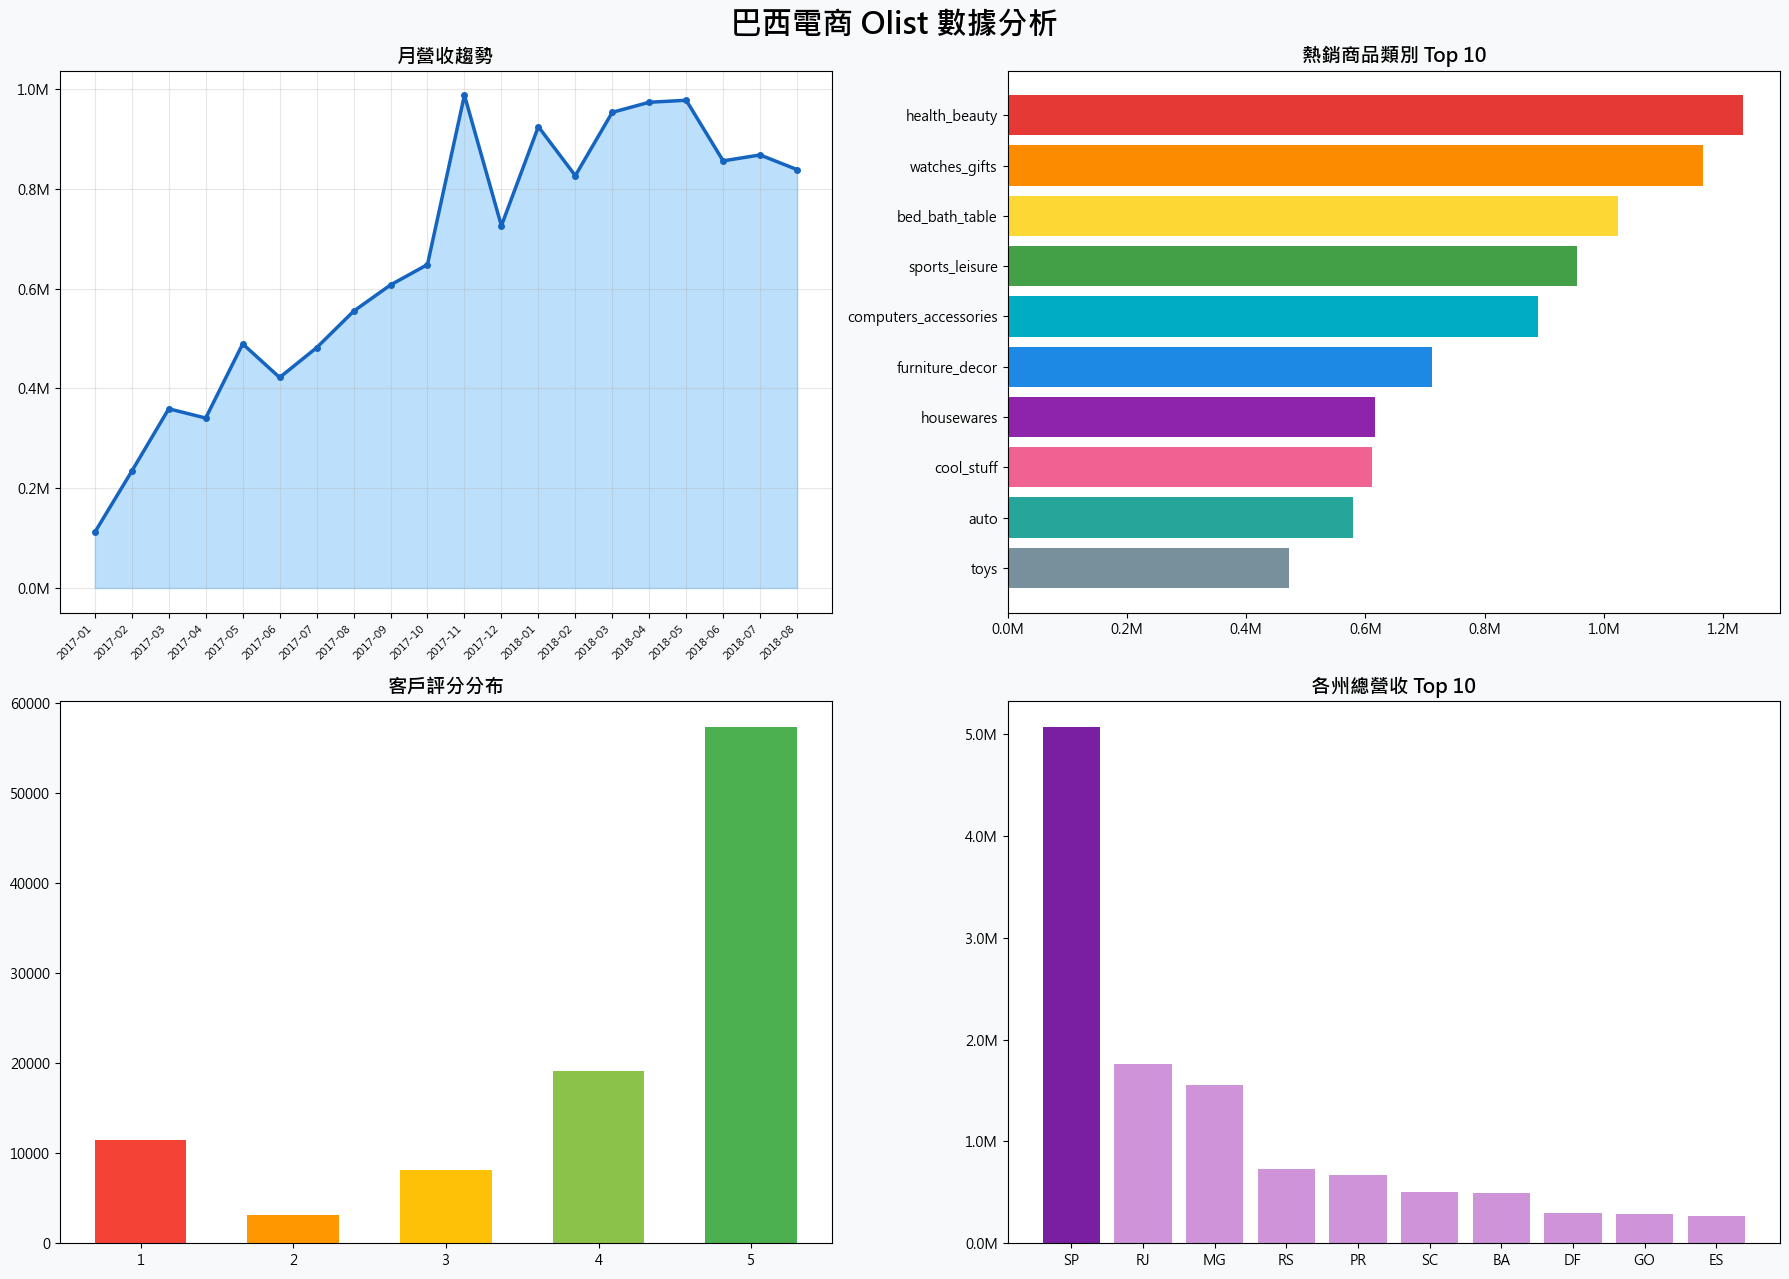

✅ 完成！


In [7]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib
matplotlib.rcParams['font.family'] = 'Microsoft JhengHei'

conn = sqlite3.connect("C:/Users/acer/olist_project/olist.db")

df_revenue = pd.read_sql("""
    SELECT strftime('%Y-%m', o.order_purchase_timestamp) AS 月份,
           ROUND(SUM(oi.price), 2) AS 總營收
    FROM orders o JOIN order_items oi ON o.order_id = oi.order_id
    WHERE o.order_status = 'delivered'
    AND strftime('%Y-%m', o.order_purchase_timestamp) >= '2017-01'
    GROUP BY 月份 ORDER BY 月份
""", conn)

df_category = pd.read_sql("""
    SELECT ct.product_category_name_english AS 商品類別,
           ROUND(SUM(oi.price), 2) AS 總營收
    FROM order_items oi
    JOIN products p ON oi.product_id = p.product_id
    JOIN category_translation ct ON p.product_category_name = ct.product_category_name
    JOIN orders o ON oi.order_id = o.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY 商品類別 ORDER BY 總營收 DESC LIMIT 10
""", conn)

df_reviews = pd.read_sql("""
    SELECT review_score AS 評分, COUNT(*) AS 數量
    FROM order_reviews GROUP BY review_score ORDER BY review_score
""", conn)

df_state = pd.read_sql("""
    SELECT c.customer_state AS 州, ROUND(SUM(oi.price), 2) AS 總營收
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id
    JOIN customers c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY 州 ORDER BY 總營收 DESC LIMIT 10
""", conn)

fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle('巴西電商 Olist 數據分析', fontsize=22, fontweight='bold')
fig.patch.set_facecolor('#F8F9FA')
fmt = mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')

# 月營收趨勢
ax1 = axes[0,0]
ax1.fill_between(range(len(df_revenue)), df_revenue['總營收'], alpha=0.3, color='#2196F3')
ax1.plot(range(len(df_revenue)), df_revenue['總營收'], color='#1565C0', linewidth=2.5, marker='o', markersize=4)
ax1.set_title('月營收趨勢', fontsize=14, fontweight='bold')
ax1.set_xticks(range(len(df_revenue)))
ax1.set_xticklabels(df_revenue['月份'], rotation=45, ha='right', fontsize=8)
ax1.yaxis.set_major_formatter(fmt)
ax1.grid(True, alpha=0.3)

# 熱銷商品類別
ax2 = axes[0,1]
colors = ['#E53935','#FB8C00','#FDD835','#43A047','#00ACC1','#1E88E5','#8E24AA','#F06292','#26A69A','#78909C']
ax2.barh(df_category['商品類別'], df_category['總營收'], color=colors)
ax2.set_title('熱銷商品類別 Top 10', fontsize=14, fontweight='bold')
ax2.xaxis.set_major_formatter(fmt)
ax2.invert_yaxis()

# 客戶評分分布
ax3 = axes[1,0]
ax3.bar(df_reviews['評分'], df_reviews['數量'], color=['#f44336','#FF9800','#FFC107','#8BC34A','#4CAF50'], width=0.6)
ax3.set_title('客戶評分分布', fontsize=14, fontweight='bold')

# 各州總營收
ax4 = axes[1,1]
ax4.bar(df_state['州'], df_state['總營收'], color=['#7B1FA2']+['#CE93D8']*9)
ax4.set_title('各州總營收 Top 10', fontsize=14, fontweight='bold')
ax4.yaxis.set_major_formatter(fmt)

plt.tight_layout()
plt.savefig('C:/Users/acer/olist_project/dashboard_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 完成！")

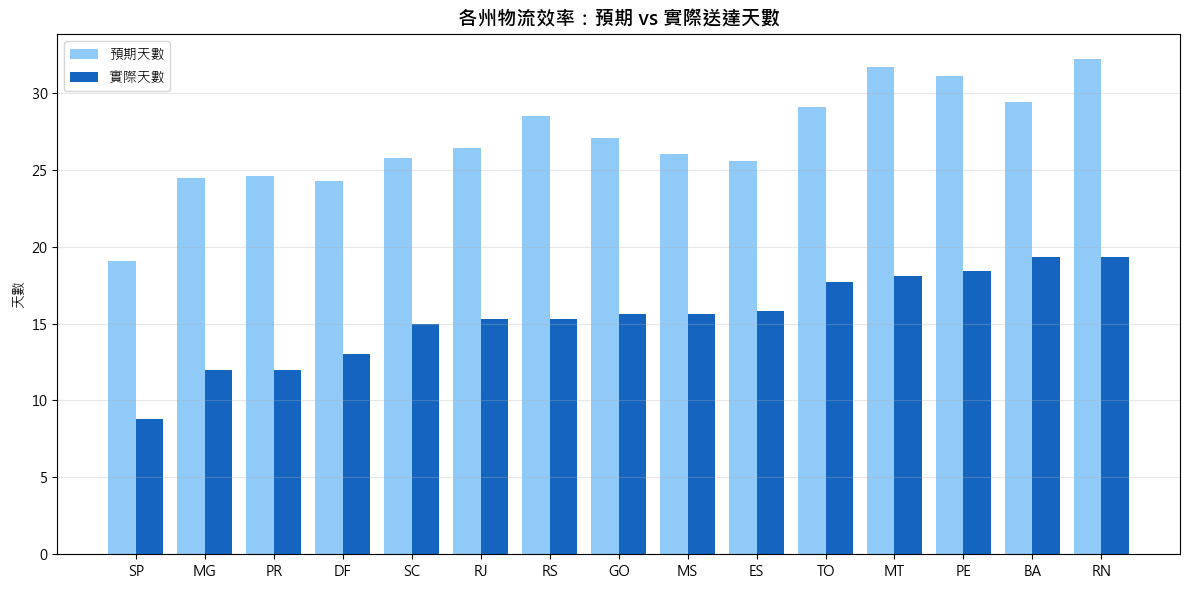

✅ 完成！


In [9]:
df_logistics = pd.read_sql("""
    SELECT 
        c.customer_state AS 州,
        ROUND(AVG(JULIANDAY(o.order_delivered_customer_date) - 
                  JULIANDAY(o.order_purchase_timestamp)), 1) AS 實際天數,
        ROUND(AVG(JULIANDAY(o.order_estimated_delivery_date) - 
                  JULIANDAY(o.order_purchase_timestamp)), 1) AS 預期天數
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    AND o.order_delivered_customer_date IS NOT NULL
    GROUP BY 州
    ORDER BY 實際天數 ASC
    LIMIT 15
""", conn)

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(df_logistics))
ax.bar(x, df_logistics['預期天數'], width=0.4, label='預期天數', color='#90CAF9', align='center')
ax.bar([i + 0.4 for i in x], df_logistics['實際天數'], width=0.4, label='實際天數', color='#1565C0', align='center')
ax.set_title('各州物流效率：預期 vs 實際送達天數', fontsize=14, fontweight='bold')
ax.set_xticks([i + 0.2 for i in x])
ax.set_xticklabels(df_logistics['州'])
ax.set_ylabel('天數')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('C:/Users/acer/olist_project/logistics.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 完成！")

In [11]:
df_revenue.to_csv('C:/Users/acer/olist_project/revenue.csv', index=False)
df_category.to_csv('C:/Users/acer/olist_project/category.csv', index=False)
df_reviews.to_csv('C:/Users/acer/olist_project/reviews.csv', index=False)
df_state.to_csv('C:/Users/acer/olist_project/state.csv', index=False)
df_logistics.to_csv('C:/Users/acer/olist_project/logistics.csv', index=False)
print("✅ 所有 CSV 匯出完成！")

✅ 所有 CSV 匯出完成！


In [13]:
# 計算 KPI
kpi = pd.read_sql("""
    SELECT 
        ROUND(SUM(oi.price)/1000000, 2) AS 總營收_M,
        COUNT(DISTINCT o.order_id) AS 總訂單數,
        ROUND(AVG(r.review_score), 1) AS 平均評分,
        ROUND(AVG(JULIANDAY(o.order_delivered_customer_date) - 
              JULIANDAY(o.order_purchase_timestamp)), 1) AS 平均送達天數
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id
    JOIN order_reviews r ON o.order_id = r.order_id
    WHERE o.order_status = 'delivered'
    AND o.order_delivered_customer_date IS NOT NULL
""", conn)

print(kpi)

   總營收_M   總訂單數  平均評分  平均送達天數
0  13.17  95824   4.1    12.4


In [15]:
kpi_detail = pd.read_sql("""
    SELECT 
        strftime('%Y', o.order_purchase_timestamp) AS 年份,
        ROUND(SUM(oi.price)/1000000, 2) AS 總營收_M,
        COUNT(DISTINCT o.order_id) AS 總訂單數,
        ROUND(AVG(r.review_score), 1) AS 平均評分,
        ROUND(AVG(JULIANDAY(o.order_delivered_customer_date) - 
              JULIANDAY(o.order_purchase_timestamp)), 1) AS 平均送達天數
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id
    JOIN order_reviews r ON o.order_id = r.order_id
    WHERE o.order_status = 'delivered'
    AND o.order_delivered_customer_date IS NOT NULL
    GROUP BY 年份
""", conn)

print(kpi_detail)
kpi_detail.to_csv('C:/Users/acer/olist_project/kpi_detail.csv', index=False)
print("✅ 完成！")

     年份  總營收_M   總訂單數  平均評分  平均送達天數
0  2016   0.04    264   3.9    19.6
1  2017   5.94  43098   4.1    12.9
2  2018   7.19  52462   4.1    12.0
✅ 完成！


In [17]:
sparkline = pd.read_sql("""
    SELECT 
        strftime('%Y-%m', o.order_purchase_timestamp) AS 月份,
        ROUND(SUM(oi.price), 2) AS 總營收,
        COUNT(DISTINCT o.order_id) AS 訂單數,
        ROUND(AVG(r.review_score), 1) AS 平均評分,
        ROUND(AVG(JULIANDAY(o.order_delivered_customer_date) - 
              JULIANDAY(o.order_purchase_timestamp)), 1) AS 平均送達天數
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id
    JOIN order_reviews r ON o.order_id = r.order_id
    WHERE o.order_status = 'delivered'
    AND o.order_delivered_customer_date IS NOT NULL
    AND strftime('%Y', o.order_purchase_timestamp) IN ('2017', '2018')
    GROUP BY 月份
    ORDER BY 月份
""", conn)

print(sparkline)
sparkline.to_csv('C:/Users/acer/olist_project/sparkline.csv', index=False)
print("✅ 完成！")

         月份        總營收   訂單數  平均評分  平均送達天數
0   2017-01  111435.03   741   4.2    12.5
1   2017-02  234295.02  1643   4.2    13.0
2   2017-03  354957.82  2527   4.1    13.0
3   2017-04  339031.50  2290   4.1    14.7
4   2017-05  488082.39  3517   4.2    11.4
5   2017-06  422742.42  3111   4.2    12.0
6   2017-07  480055.78  3842   4.2    11.4
7   2017-08  553093.68  4165   4.3    10.9
8   2017-09  605959.16  4118   4.2    11.8
9   2017-10  645109.30  4446   4.1    11.7
10  2017-11  986080.75  7237   3.9    15.0
11  2017-12  718683.08  5461   4.0    15.2
12  2018-01  920968.82  7013   4.0    14.1
13  2018-02  829477.41  6507   3.8    16.9
14  2018-03  946926.22  6948   3.7    15.9
15  2018-04  970279.98  6752   4.1    11.3
16  2018-05  972779.22  6722   4.2    11.3
17  2018-06  854424.79  6072   4.2     9.1
18  2018-07  857453.37  6118   4.3     8.9
19  2018-08  835346.37  6330   4.2     7.7
✅ 完成！


In [19]:
growth = pd.read_sql("""
    SELECT 
        ROUND(SUM(CASE WHEN strftime('%Y', o.order_purchase_timestamp) = '2018' 
                  THEN oi.price ELSE 0 END) / 1000000, 2) AS 營收_2018,
        ROUND(SUM(CASE WHEN strftime('%Y', o.order_purchase_timestamp) = '2017' 
                  THEN oi.price ELSE 0 END) / 1000000, 2) AS 營收_2017,
        COUNT(DISTINCT CASE WHEN strftime('%Y', o.order_purchase_timestamp) = '2018' 
                  THEN o.order_id END) AS 訂單_2018,
        COUNT(DISTINCT CASE WHEN strftime('%Y', o.order_purchase_timestamp) = '2017' 
                  THEN o.order_id END) AS 訂單_2017,
        ROUND(AVG(CASE WHEN strftime('%Y', o.order_purchase_timestamp) = '2018' 
                  THEN r.review_score END), 1) AS 評分_2018,
        ROUND(AVG(CASE WHEN strftime('%Y', o.order_purchase_timestamp) = '2017' 
                  THEN r.review_score END), 1) AS 評分_2017
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id
    JOIN order_reviews r ON o.order_id = r.order_id
    WHERE o.order_status = 'delivered'
""", conn)

print(growth)
growth.to_csv('C:/Users/acer/olist_project/growth.csv', index=False)
print("✅ 完成！")

   營收_2018  營收_2017  訂單_2018  訂單_2017  評分_2018  評分_2017
0     7.19     5.94    52468    43100      4.1      4.1
✅ 完成！
